# NB_LightAug_AllFeatures

**Augmentation strategy: Light Aug: Flip+Brightness**

All other features identical across all 4 notebooks:
- Grad-CAM, t-SNE, ROC/PR curves, misclassification heatmap
- Complexity table (FLOPs, inference time, memory)
- Bootstrap confidence intervals
- Confusion matrix, per-class metrics

> Test metrics are on the held-out test set (15%, ~4,256 samples).


In [1]:
!pip install kaggle tensorflow scikit-learn matplotlib seaborn pandas numpy Pillow tqdm psutil -q
print('OK')


OK


In [2]:
import os,math,random,json,warnings,zipfile,shutil,time,tracemalloc,psutil,gc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from collections import defaultdict
from itertools import cycle
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,Conv2D,MaxPooling2D,GlobalAveragePooling2D,BatchNormalization,
    Dense,Dropout,Add,Concatenate,Multiply,Reshape,Layer
)
from tensorflow.keras.callbacks import LearningRateScheduler,EarlyStopping,ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,confusion_matrix,
    accuracy_score,precision_score,recall_score,f1_score,
    roc_curve,auc,precision_recall_curve,average_precision_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.manifold import TSNE

gpus = tf.config.list_physical_devices('GPU')
for g in gpus: tf.config.experimental.set_memory_growth(g,True)
print('TF ' + tf.__version__ + ' | GPUs: ' + str(len(gpus)))


2026-05-02 19:15:12.764028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777749312.920343      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777749312.963592      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777749313.311157      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777749313.311196      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777749313.311199      57 computation_placer.cc:177] computation placer alr

TF 2.19.0 | GPUs: 2


In [3]:
NOTEBOOK_ID  = "NB_LightAug_AllFeatures"
AUG_STRATEGY = "Light Aug: Flip+Brightness"
SEED=42; IMG_SIZE=(256,256); IMG_SHAPE=(256,256,3)
BATCH_SIZE=64; INITIAL_LR=1e-3; EPOCHS=60; DROPOUT_RATE=0.4
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

TARGET_CLASSES = ['Wheat_Brown_rust', 'Wheat_Healthy', 'Wheat_Yellow_rust', 'Potato_Early_blight', 'Potato_Late_blight', 'Potato_Healthy', 'Bell_Pepper_Bacterial_spot', 'Bell_Pepper_Healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites', 'Tomato_Target_spot', 'Tomato_Yellowleaf_curl_virus', 'Tomato_Mosaic_virus', 'Tomato_Healthy']
NUM_CLASSES    = len(TARGET_CLASSES)
CLASS_TO_IDX   = {c:i for i,c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS   = {i:c for i,c in enumerate(TARGET_CLASSES)}
TARGET_COUNTS  = {'Wheat_Brown_rust': 902, 'Wheat_Healthy': 1116, 'Wheat_Yellow_rust': 924, 'Potato_Early_blight': 1000, 'Potato_Late_blight': 1000, 'Potato_Healthy': 152, 'Bell_Pepper_Bacterial_spot': 997, 'Bell_Pepper_Healthy': 1478, 'Tomato_Bacterial_spot': 2127, 'Tomato_Early_blight': 1000, 'Tomato_Late_blight': 1909, 'Tomato_Leaf_mold': 952, 'Tomato_Septoria_leaf_spot': 1771, 'Tomato_Spider_mites': 1676, 'Tomato_Target_spot': 1404, 'Tomato_Yellowleaf_curl_virus': 3209, 'Tomato_Mosaic_virus': 373, 'Tomato_Healthy': 1591}
KAGGLE_DATASETS= [
    ('mohitsingh1804/plantvillage',    'plantvillage'),
    ('sinadunk23/behzad-safari-jalal', 'behzad-safari-jalal'),
]
VALID_EXTS = {'.jpg','.jpeg','.png','.bmp','.tif','.tiff'}

BASE_DIR    = os.path.join(os.path.expanduser('~'),'plant_project',NOTEBOOK_ID)
RAW_DIR     = os.path.join(os.path.expanduser('~'),'plant_project','raw')
UNIFIED_DIR = os.path.join(BASE_DIR,'unified')
CKPT_DIR    = os.path.join(BASE_DIR,'checkpoints')
LOG_DIR     = os.path.join(BASE_DIR,'logs')
VIZ_DIR     = os.path.join(LOG_DIR,'visualizations')
for d in [BASE_DIR,RAW_DIR,UNIFIED_DIR,CKPT_DIR,LOG_DIR,VIZ_DIR]: os.makedirs(d,exist_ok=True)

def get_images(folder):
    if not os.path.isdir(folder): return []
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in VALID_EXTS]
print('Config done: ' + NOTEBOOK_ID + ' | ' + AUG_STRATEGY)


Config done: NB_LightAug_AllFeatures | Light Aug: Flip+Brightness


In [4]:
KAGGLE_USERNAME="jyotiradityachillal"; KAGGLE_KEY="KGAT_bba51b5487bd42a6dc26ac9524d520f9"
import json as _j; kd=os.path.expanduser("~/.kaggle"); os.makedirs(kd,exist_ok=True)
with open(os.path.join(kd,"kaggle.json"),"w") as f: _j.dump({"username":KAGGLE_USERNAME,"key":KAGGLE_KEY},f)
os.chmod(os.path.join(kd,"kaggle.json"),0o600)
os.environ["KAGGLE_USERNAME"]=KAGGLE_USERNAME; os.environ["KAGGLE_KEY"]=KAGGLE_KEY
print("Kaggle credentials set.")


Kaggle credentials set.


In [5]:
orig=os.getcwd(); os.chdir(RAW_DIR)
for ds_slug,folder_name in KAGGLE_DATASETS:
    tf_dir=os.path.join(RAW_DIR,folder_name); zf=os.path.join(RAW_DIR,folder_name+'.zip')
    if os.path.isdir(tf_dir) and os.listdir(tf_dir): print('  Ready: '+folder_name+'/'); continue
    if not os.path.isfile(zf): os.system('kaggle datasets download -d '+ds_slug+' --quiet')
    with zipfile.ZipFile(zf,'r') as z: z.extractall(tf_dir)
    print('  Extracted: '+folder_name)
os.chdir(orig); print('Done.')


Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
  Extracted: plantvillage
Dataset URL: https://www.kaggle.com/datasets/sinadunk23/behzad-safari-jalal
License(s): unknown
  Extracted: behzad-safari-jalal
Done.


In [6]:
FOLDER_MAP={
    'pepper,_bell___bacterial_spot':'Bell_Pepper_Bacterial_spot','pepper___bacterial_spot':'Bell_Pepper_Bacterial_spot','bell_pepper___bacterial_spot':'Bell_Pepper_Bacterial_spot',
    'pepper,_bell___healthy':'Bell_Pepper_Healthy','pepper___healthy':'Bell_Pepper_Healthy','bell_pepper___healthy':'Bell_Pepper_Healthy',
    'potato___early_blight':'Potato_Early_blight','potato___late_blight':'Potato_Late_blight','potato___healthy':'Potato_Healthy',
    'tomato___bacterial_spot':'Tomato_Bacterial_spot','tomato___early_blight':'Tomato_Early_blight','tomato___late_blight':'Tomato_Late_blight',
    'tomato___leaf_mold':'Tomato_Leaf_mold','tomato___septoria_leaf_spot':'Tomato_Septoria_leaf_spot',
    'tomato___spider_mites two-spotted_spider_mite':'Tomato_Spider_mites','tomato___spider_mites_two-spotted_spider_mite':'Tomato_Spider_mites',
    'tomato___target_spot':'Tomato_Target_spot','tomato___tomato_yellow_leaf_curl_virus':'Tomato_Yellowleaf_curl_virus',
    'tomato___tomato_mosaic_virus':'Tomato_Mosaic_virus','tomato___healthy':'Tomato_Healthy',
    'brown rust':'Wheat_Brown_rust','brown_rust':'Wheat_Brown_rust','brownrust':'Wheat_Brown_rust',
    'yellow rust':'Wheat_Yellow_rust','yellow_rust':'Wheat_Yellow_rust','yellowrust':'Wheat_Yellow_rust',
    'wheat_healthy':'Wheat_Healthy','wheat healthy':'Wheat_Healthy','wheat___healthy':'Wheat_Healthy',
}
HEALTHY_CTX={'wheat':'Wheat_Healthy','potato':'Potato_Healthy','behzad':'Wheat_Healthy','jalal':'Wheat_Healthy'}
def resolve_class(p):
    name=os.path.basename(p).lower().strip()
    if name in FOLDER_MAP: return FOLDER_MAP[name]
    if name in ('healthy','normal','disease free'):
        fl=p.lower()
        for k,v in HEALTHY_CTX.items():
            if k in fl: return v
    return None

class_files=defaultdict(list)
for _,folder in KAGGLE_DATASETS:
    ds_root=os.path.join(RAW_DIR,folder)
    if not os.path.isdir(ds_root): continue
    for dp,_,fnames in os.walk(ds_root):
        imgs=[f for f in fnames if os.path.splitext(f)[1].lower() in VALID_EXTS]
        if not imgs: continue
        cls=resolve_class(dp)
        if cls and cls in TARGET_CLASSES: class_files[cls].extend([os.path.join(dp,f) for f in imgs])

print('Scan:')
for cls in TARGET_CLASSES:
    n=len(class_files[cls]); flag=' <- MISSING' if n==0 else ''
    print('  '+cls.ljust(40)+str(n).rjust(5)+flag)


Scan:
  Wheat_Brown_rust                         1128
  Wheat_Healthy                            1395
  Wheat_Yellow_rust                        1156
  Potato_Early_blight                      1000
  Potato_Late_blight                       1000
  Potato_Healthy                            152
  Bell_Pepper_Bacterial_spot                997
  Bell_Pepper_Healthy                      1478
  Tomato_Bacterial_spot                    2127
  Tomato_Early_blight                      1000
  Tomato_Late_blight                       1909
  Tomato_Leaf_mold                          952
  Tomato_Septoria_leaf_spot                1771
  Tomato_Spider_mites                      1676
  Tomato_Target_spot                       1404
  Tomato_Yellowleaf_curl_virus             5357
  Tomato_Mosaic_virus                       373
  Tomato_Healthy                           1591


In [7]:
random.seed(SEED); actual_counts={}
for cls in TARGET_CLASSES:
    cls_dir=os.path.join(UNIFIED_DIR,cls); os.makedirs(cls_dir,exist_ok=True)
    ex=get_images(cls_dir)
    if ex: actual_counts[cls]=len(ex); continue
    srcs=class_files[cls][:]; random.shuffle(srcs); srcs=srcs[:TARGET_COUNTS.get(cls,999999)]
    for i,src in enumerate(srcs):
        ext=os.path.splitext(src)[1].lower() or '.jpg'
        dst=os.path.join(cls_dir,str(i).zfill(5)+ext)
        if not os.path.exists(dst): shutil.copy2(src,dst)
    actual_counts[cls]=len(srcs)

all_paths,all_labels=[],[]
for cls in TARGET_CLASSES:
    imgs=get_images(os.path.join(UNIFIED_DIR,cls))
    all_paths.extend(imgs); all_labels.extend([CLASS_TO_IDX[cls]]*len(imgs))
all_paths=np.array(all_paths); all_labels=np.array(all_labels,dtype=np.int32)

present=np.unique(all_labels); cw_vals=compute_class_weight('balanced',classes=present,y=all_labels)
class_weights={i:1.0 for i in range(NUM_CLASSES)}
for idx,w in zip(present,cw_vals): class_weights[idx]=w
print('Dataset: '+str(len(all_paths))+' images | '+str(NUM_CLASSES)+' classes')


Dataset: 23581 images | 18 classes


I0000 00:00:1777749416.834545      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777749416.861322      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


LIGHT aug | Train 16506 Val 3537 Test 3538


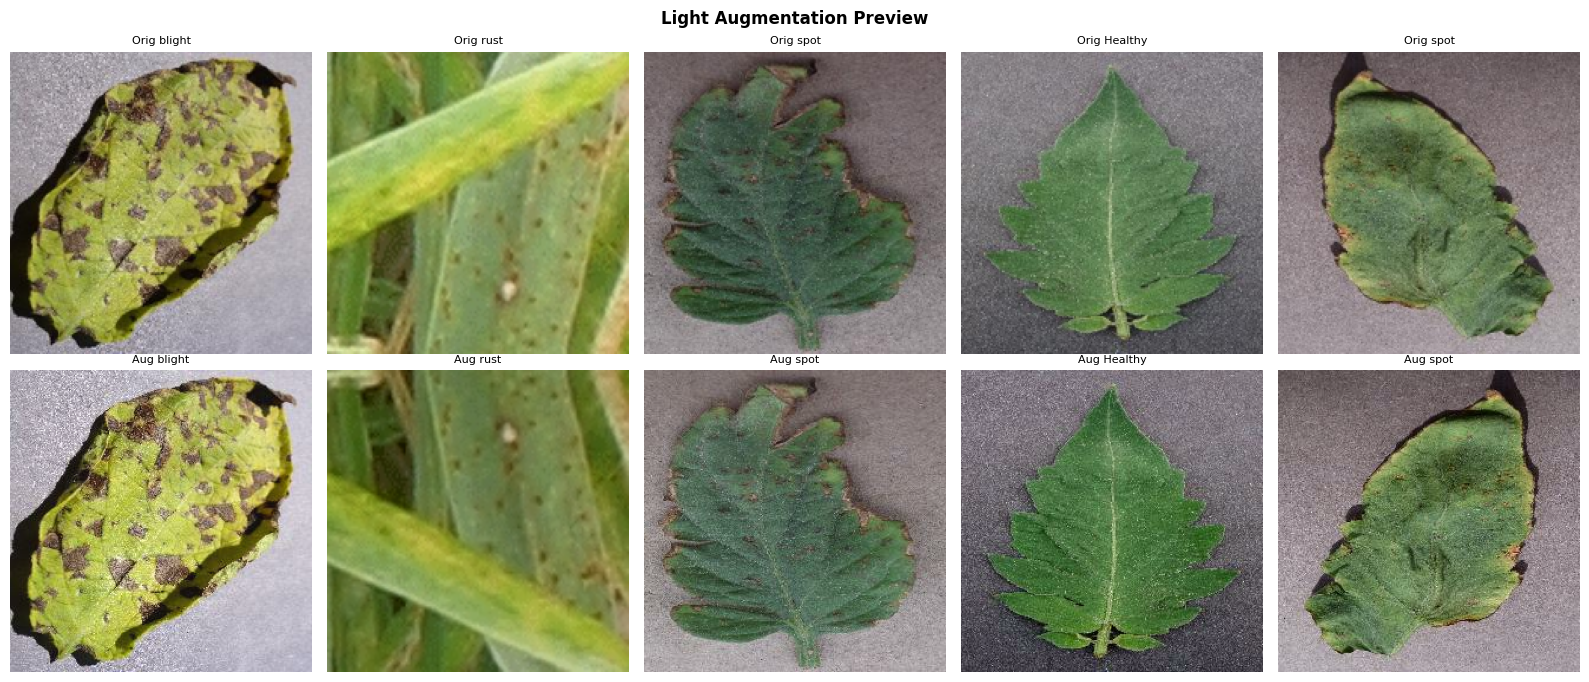

In [8]:
# AUGMENTATION: LIGHT (flip + brightness/contrast)
AUTOTUNE = tf.data.AUTOTUNE
USE_MIXUP = False

def load_img(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32)/255.0, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    return tf.clip_by_value(img, 0.0, 1.0), label

def make_ds(paths, labels, training=False, use_mixup=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training: ds = ds.shuffle(min(len(paths),10000), seed=SEED)
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE)
    if training: ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

X_tr,X_tmp,y_tr,y_tmp = train_test_split(all_paths,all_labels,test_size=0.30,random_state=SEED,stratify=all_labels)
X_val,X_te,y_val,y_te = train_test_split(X_tmp,y_tmp,test_size=0.50,random_state=SEED,stratify=y_tmp)
train_ds = make_ds(X_tr,y_tr,training=True)
val_ds   = make_ds(X_val,y_val); test_ds = make_ds(X_te,y_te)

LOSS_FN = 'sparse_categorical_crossentropy'
CLASS_WEIGHTS_TRAIN = class_weights
print('LIGHT aug | Train '+str(len(X_tr))+' Val '+str(len(X_val))+' Test '+str(len(X_te)))

random.seed(SEED); sample_cls_aug = random.sample(TARGET_CLASSES,5)
fig,axes=plt.subplots(2,5,figsize=(16,7))
for col,cls in enumerate(sample_cls_aug):
    path=random.choice(get_images(os.path.join(UNIFIED_DIR,cls)))
    axes[0,col].imshow(Image.open(path).convert('RGB').resize((200,200)))
    axes[0,col].set_title('Orig '+cls.split('_')[-1],fontsize=8); axes[0,col].axis('off')
    raw=tf.io.read_file(path)
    img_t=tf.cast(tf.image.resize(tf.image.decode_image(raw,channels=3,expand_animations=False),IMG_SIZE),tf.float32)/255.0
    aug_img,_=augment(img_t,0)
    axes[1,col].imshow(aug_img.numpy())
    axes[1,col].set_title('Aug '+cls.split('_')[-1],fontsize=8); axes[1,col].axis('off')
fig.suptitle('Light Augmentation Preview',fontweight='bold'); plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'aug_preview.png'),dpi=120,bbox_inches='tight'); plt.show()


In [9]:
class Inception_cell(Layer):
    """3 parallel convolutions (3×3, 5×5, 7×7) combined by element-wise Add."""
    def __init__(self,num_filters,activation='relu',padding='same',**kwargs):
        super().__init__(**kwargs)
        self.num_filters=num_filters; self.activation=activation; self.padding=padding
        self.conv3=Conv2D(num_filters,(3,3),activation=activation,padding=padding)
        self.conv5=Conv2D(num_filters,(5,5),activation=activation,padding=padding)
        self.conv7=Conv2D(num_filters,(7,7),activation=activation,padding=padding)
    def call(self,x,training=False):
        return Add()([self.conv3(x),self.conv5(x),self.conv7(x)])
    def get_config(self):
        cfg=super().get_config()
        cfg.update({'num_filters':self.num_filters,'activation':self.activation,'padding':self.padding})
        return cfg

class SkipConnection(Layer):
    """Conv7×7 → BN → Concatenate(input) — DenseNet-style skip."""
    def __init__(self,num_filters,kernel_size=7,activation='relu',padding='same',**kwargs):
        super().__init__(**kwargs)
        self.num_filters=num_filters; self.kernel_size=kernel_size
        self.conv=Conv2D(num_filters,(7,7),activation=activation,padding=padding)
        self.bn=BatchNormalization()
    def call(self,x,training=False):
        out=self.conv(x); out=self.bn(out,training=training)
        return Concatenate(axis=-1)([out,x])
    def get_config(self):
        cfg=super().get_config()
        cfg.update({'num_filters':self.num_filters,'kernel_size':self.kernel_size})
        return cfg

print('Inception_cell + SkipConnection defined.')


class CosineWarmupScheduler(LearningRateScheduler):
    def __init__(self,initial_lr,total_epochs,warmup_epochs=5):
        self.initial_lr=initial_lr; self.total_epochs=total_epochs; self.warmup=warmup_epochs
        super().__init__(self._sched,verbose=0)
    def _sched(self,epoch,lr):
        if epoch<self.warmup: return self.initial_lr*(epoch+1)/self.warmup
        t=epoch-self.warmup; T=self.total_epochs-self.warmup
        return 0.5*self.initial_lr*(1+math.cos(math.pi*t/T))
    def get_config(self):
        cfg=super().get_config(); cfg.update({'initial_lr':self.initial_lr,'total_epochs':self.total_epochs,'warmup_epochs':self.warmup}); return cfg

def build_model():
    inp=Input(shape=IMG_SHAPE)
    x=Inception_cell(16,name='inc_se_1')(inp); x=BatchNormalization()(x); x=MaxPooling2D((2,2))(x)
    x=Inception_cell(32,name='inc_se_2')(x);   x=BatchNormalization()(x); x=MaxPooling2D((2,2))(x)
    x=SkipConnection(64,name='skip_se_1')(x); x=MaxPooling2D((2,2))(x)
    x=SkipConnection(128,name='skip_se_2')(x); x=MaxPooling2D((2,2))(x)
    x=GlobalAveragePooling2D(name='gap')(x)
    x=Dense(512,activation='relu')(x); x=Dropout(DROPOUT_RATE)(x)
    x=Dense(128,activation='relu')(x); x=Dropout(0.3)(x)
    out=Dense(NUM_CLASSES,activation='softmax')(x)
    return Model(inp,out,name='Proposed2_SE_'+NOTEBOOK_ID)

model=build_model(); model.summary()
print('Params: '+str(model.count_params()))


Inception_cell + SkipConnection defined.


Model: "Proposed2_SE_NB_LightAug_AllFeatures"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc_se_1 (Inception_cell)       │ (None, 256, 256, 16)   │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc_se_2 (Inception_cell)       │ (None, 128, 128, 32)   │        42,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skip_se_1 (SkipConnection)      │ (None, 64, 64, 96)     │       100,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skip_se_2 (SkipConnection)      │ (None, 32, 32, 224)    │       602,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 933,426 (3.56 MB)

 Trainable params: 932,946 (3.56 MB)

 Non-trainable params: 480 (1.88 KB)

Params: 933426


In [10]:
ckpt_path=os.path.join(CKPT_DIR,'best.weights.h5')
model.compile(optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
              loss=LOSS_FN, metrics=['accuracy'])
callbacks=[
    CosineWarmupScheduler(INITIAL_LR,EPOCHS,warmup_epochs=5),
    ModelCheckpoint(ckpt_path,monitor='val_accuracy',save_best_only=True,
                    save_weights_only=True,verbose=0),
]
tracemalloc.start(); t0=time.time()
history=model.fit(train_ds,epochs=EPOCHS,validation_data=val_ds,
                  class_weight=CLASS_WEIGHTS_TRAIN,
                  callbacks=callbacks,verbose=1)
train_time=time.time()-t0
_,peak_mem=tracemalloc.get_traced_memory(); tracemalloc.stop()
ram_used_mb=psutil.Process().memory_info().rss/1e6
print('Done '+str(round(train_time/60,1))+' min | RAM '+str(round(ram_used_mb,0))+'MB | AUG='+AUG_STRATEGY)


Epoch 1/60


I0000 00:00:1777749434.338552     137 service.cc:152] XLA service 0x7c889c20a390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777749434.338604     137 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777749434.338608     137 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777749435.553803     137 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-02 19:17:24.829356: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 19:17:24.984303: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 19:17:27.052819: E external/local_xl

257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.2798 - loss: 2.2905

2026-05-02 19:18:57.197918: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 19:18:57.351239: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 19:18:59.492809: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 19:18:59.784687: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 19:19:01.060105: E external/local_xla/xla/stream_

258/258 ━━━━━━━━━━━━━━━━━━━━ 148s 414ms/step - accuracy: 0.2808 - loss: 2.2871 - val_accuracy: 0.0919 - val_loss: 5.7752 - learning_rate: 2.0000e-04
Epoch 2/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 70s 272ms/step - accuracy: 0.5713 - loss: 1.2775 - val_accuracy: 0.5867 - val_loss: 1.2223 - learning_rate: 4.0000e-04
Epoch 3/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 70s 271ms/step - accuracy: 0.6644 - loss: 0.9586 - val_accuracy: 0.5671 - val_loss: 1.4580 - learning_rate: 6.0000e-04
Epoch 4/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 70s 271ms/step - accuracy: 0.7265 - loss: 0.7744 - val_accuracy: 0.8202 - val_loss: 0.5357 - learning_rate: 8.0000e-04
Epoch 5/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 70s 269ms/step - accuracy: 0.7803 - loss: 0.6302 - val_accuracy: 0.7560 - val_loss: 0.7446 - learning_rate: 0.0010
Epoch 6/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 70s 270ms/step - accuracy: 0.8328 - loss: 0.4627 - val_accuracy: 0.7676 - val_loss: 0.6521 - learning_rate: 0.0010
Epoch 7/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 70s 270ms/step - accurac

## Results — Test Set Evaluation
> All metrics on the held-out test set (~4,256 images). Never seen during training.


In [11]:
ckpt_path=os.path.join(CKPT_DIR,'best.weights.h5')
if os.path.exists(ckpt_path): model.load_weights(ckpt_path); print('Best weights loaded.')

y_prob=model.predict(test_ds,verbose=1)
y_pred=np.argmax(y_prob,axis=1)
raw_true=[]
for _,yl in test_ds:
    yl_np=yl.numpy()
    if yl_np.ndim==2: raw_true.extend(np.argmax(yl_np,axis=1))
    else: raw_true.extend(yl_np.astype(int))
y_true=np.array(raw_true[:len(y_pred)],dtype=int)

acc  =accuracy_score(y_true,y_pred)
prec =precision_score(y_true,y_pred,average='weighted',zero_division=0)
rec  =recall_score(y_true,y_pred,average='weighted',zero_division=0)
f1   =f1_score(y_true,y_pred,average='weighted',zero_division=0)
rd   =classification_report(y_true,y_pred,labels=list(range(NUM_CLASSES)),
       target_names=TARGET_CLASSES,output_dict=True,zero_division=0)
spec_list=[]
for i in range(NUM_CLASSES):
    tp=np.sum((y_true==i)&(y_pred==i)); fp=np.sum((y_true!=i)&(y_pred==i))
    tn=np.sum((y_true!=i)&(y_pred!=i))
    spec_list.append(tn/(tn+fp) if (tn+fp)>0 else 0)

print('Augmentation : '+AUG_STRATEGY)
print('Accuracy     : '+str(round(acc,4))+' ('+str(round(acc*100,2))+'%)')
print('Precision    : '+str(round(prec,4)))
print('Recall       : '+str(round(rec,4)))
print('F1-Score     : '+str(round(f1,4)))
print('Specificity  : '+str(round(float(np.mean(spec_list)),4)))


Best weights loaded.
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step
Augmentation : Light Aug: Flip+Brightness
Accuracy     : 0.9946 (99.46%)
Precision    : 0.9947
Recall       : 0.9946
F1-Score     : 0.9946
Specificity  : 0.9997


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


I0000 00:00:1777753686.321371      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1777753686.321631      57 single_machine.cc:374] Starting new session
I0000 00:00:1777753686.334982      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777753686.336351      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

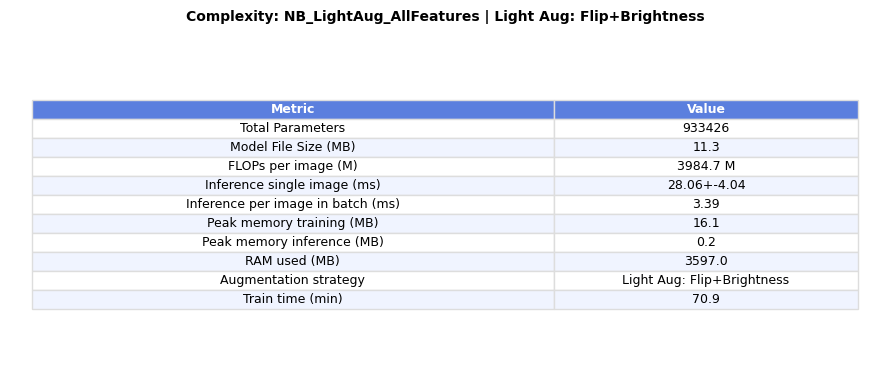

Complexity table saved.


In [12]:
# 1. Computational Complexity Table
import time as _t

try:
    from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2
    concrete = tf.function(model).get_concrete_function(
        tf.TensorSpec([1] + list(IMG_SHAPE), tf.float32))
    frozen = convert_variables_to_constants_v2(concrete)
    graph  = frozen.graph
    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops_val = tf.compat.v1.profiler.profile(
        graph=graph, run_meta=run_meta, cmd='op', options=opts)
    total_flops = flops_val.total_float_ops
    flops_str = str(round(total_flops / 1e6, 1)) + ' M'
except Exception as e:
    total_flops = -1
    flops_str = 'N/A (' + str(e)[:40] + ')'
    
dummy=tf.random.normal([1]+list(IMG_SHAPE))
for _ in range(3): model(dummy,training=False)
times_s=[]
for img,_ in test_ds.unbatch().batch(1).take(50):
    t0=_t.perf_counter(); model(img,training=False); times_s.append((_t.perf_counter()-t0)*1000)
times_b=[]
for img,_ in test_ds.take(20):
    t0=_t.perf_counter(); model(img,training=False); times_b.append((_t.perf_counter()-t0)*1000)

single_ms=np.mean(times_s); per_img_ms=np.mean(times_b)/BATCH_SIZE
tracemalloc.start()
for img,_ in test_ds.take(5): model(img,training=False)
_,inf_peak=tracemalloc.get_traced_memory(); tracemalloc.stop()
tmp_p='/tmp/_sz.h5'; model.save(tmp_p); sz_mb=os.path.getsize(tmp_p)/1e6; os.remove(tmp_p)

comp_df=pd.DataFrame({'Metric':[
    'Total Parameters','Model File Size (MB)','FLOPs per image (M)',
    'Inference single image (ms)','Inference per image in batch (ms)',
    'Peak memory training (MB)','Peak memory inference (MB)','RAM used (MB)',
    'Augmentation strategy','Train time (min)'],
'Value':[str(model.count_params()),str(round(sz_mb,2)),flops_str,
    str(round(single_ms,2))+'+-'+str(round(np.std(times_s),2)),str(round(per_img_ms,2)),
    str(round(peak_mem/1e6,1)),str(round(inf_peak/1e6,1)),str(round(ram_used_mb,0)),
    AUG_STRATEGY,str(round(train_time/60,1))]})
comp_df.to_csv(os.path.join(LOG_DIR,'complexity.csv'),index=False)

fig,ax=plt.subplots(figsize=(9,4)); ax.axis('off')
tbl=ax.table(cellText=comp_df.values,colLabels=['Metric','Value'],
             cellLoc='center',loc='center',colWidths=[0.6,0.35])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r,c),cell in tbl.get_celld().items():
    if r==0: cell.set_facecolor('#5B7FDE'); cell.set_text_props(color='white',weight='bold')
    elif r%2==0: cell.set_facecolor('#F0F4FF')
    cell.set_edgecolor('#DDD')
ax.set_title('Complexity: '+NOTEBOOK_ID+' | '+AUG_STRATEGY,fontweight='bold',fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'complexity_table.png'),dpi=130,bbox_inches='tight'); plt.show()
print('Complexity table saved.')


Top 5 confusions:
  True=Tomato_Late_blight                  Pred=Tomato_Early_blight                 n=4
  True=Tomato_Septoria_leaf_spot           Pred=Bell_Pepper_Bacterial_spot          n=3
  True=Tomato_Target_spot                  Pred=Tomato_Spider_mites                 n=2
  True=Tomato_Bacterial_spot               Pred=Tomato_Yellowleaf_curl_virus        n=2
  True=Wheat_Brown_rust                    Pred=Wheat_Yellow_rust                   n=1


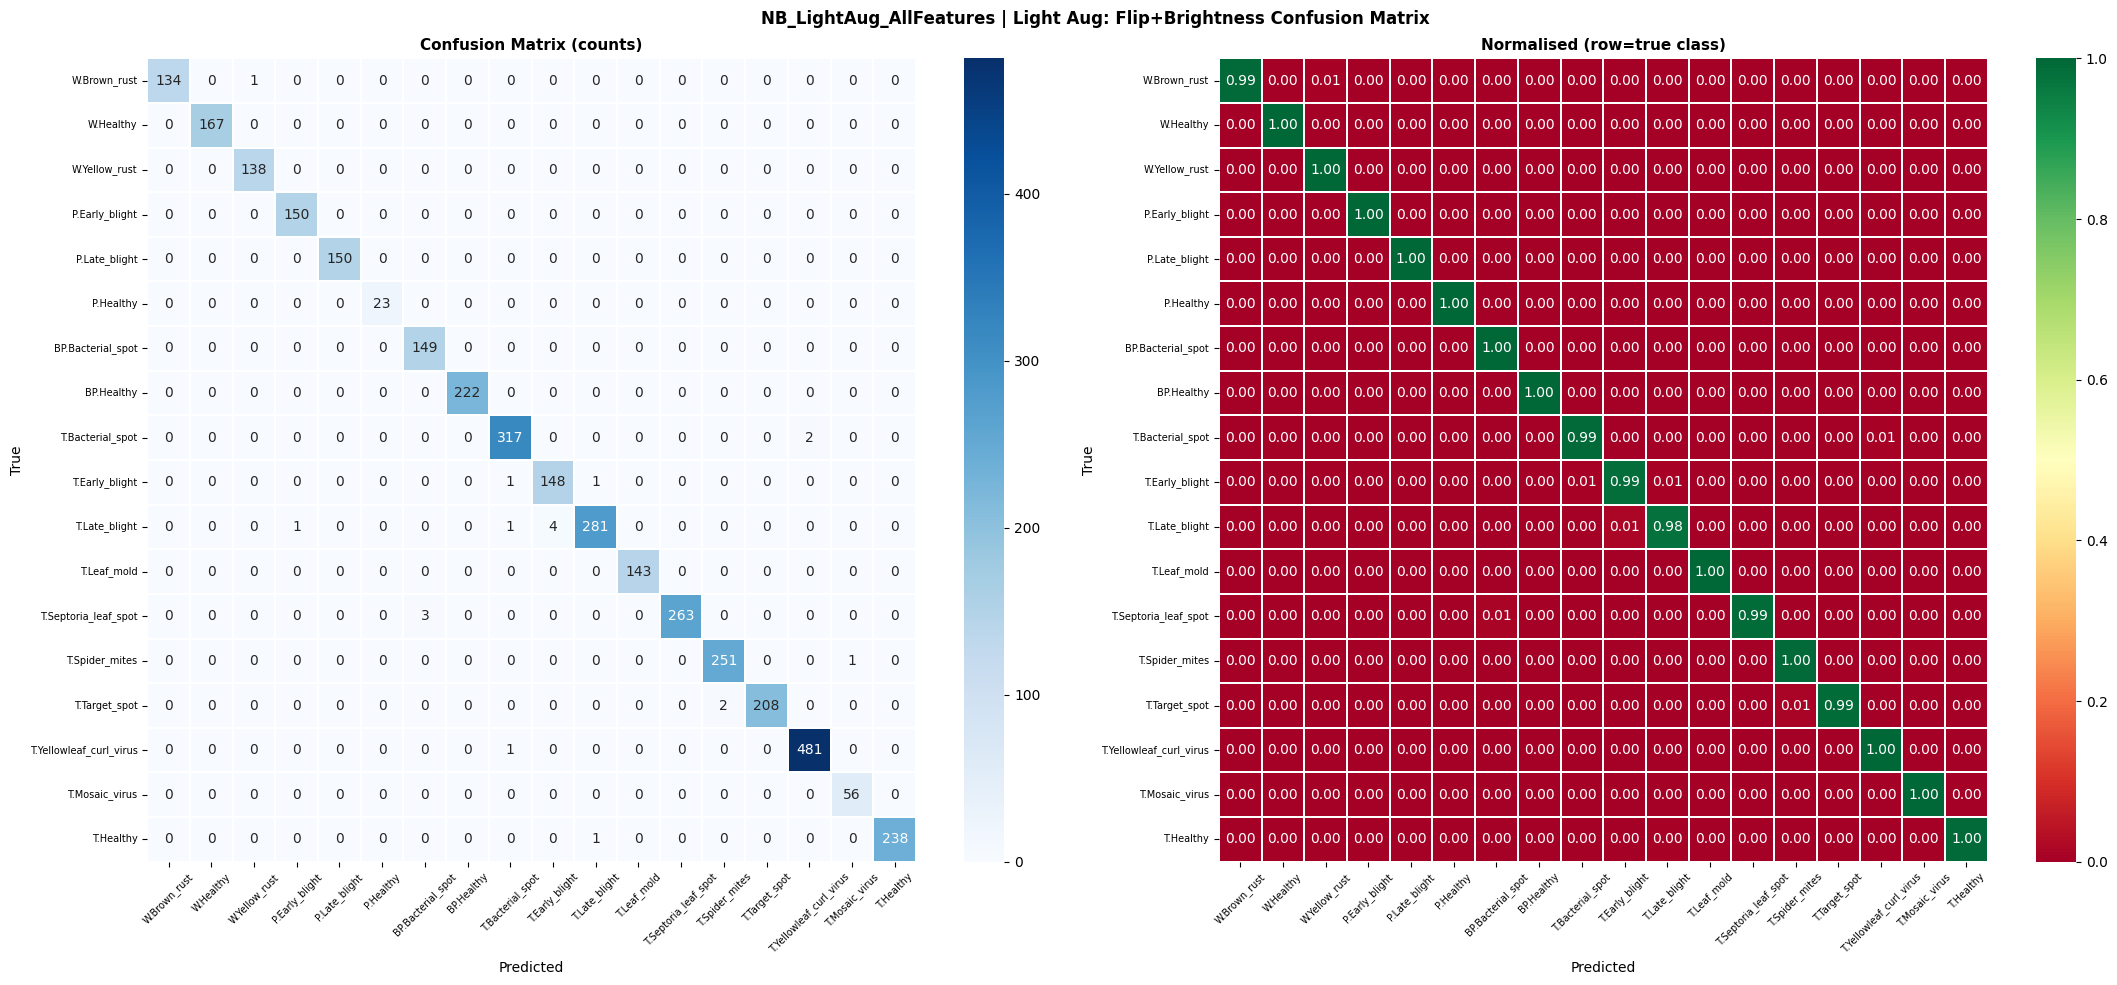

In [13]:
# 2. Confusion Matrix
cm=confusion_matrix(y_true,y_pred)
cm_norm=cm.astype(float)/np.maximum(cm.sum(axis=1,keepdims=True),1)
short=[c.replace('Cotton_','C.').replace('Wheat_','W.').replace('Potato_','P.')
        .replace('Bell_Pepper_','BP.').replace('Tomato_','T.') for c in TARGET_CLASSES]

fig,axes=plt.subplots(1,2,figsize=(22,10))
for ax,data,fmt,cmap,title in [
    (axes[0],cm,'d','Blues','Confusion Matrix (counts)'),
    (axes[1],cm_norm,'.2f','RdYlGn','Normalised (row=true class)'),
]:
    sns.heatmap(data,ax=ax,cmap=cmap,fmt=fmt,annot=True,
                xticklabels=short,yticklabels=short,
                linewidths=0.3,linecolor='white',
                **({'vmin':0,'vmax':1} if fmt=='.2f' else {}))
    ax.set_title(title,fontweight='bold',fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x',rotation=45,labelsize=7); ax.tick_params(axis='y',rotation=0,labelsize=7)

top5=sorted([(cm[i,j],TARGET_CLASSES[i],TARGET_CLASSES[j])
              for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i!=j],reverse=True)[:5]
print('Top 5 confusions:')
for cnt,t,p in top5: print('  True='+t.ljust(35)+' Pred='+p.ljust(35)+' n='+str(cnt))

plt.suptitle(NOTEBOOK_ID+' | '+AUG_STRATEGY+' Confusion Matrix',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'confusion_matrix.png'),dpi=130,bbox_inches='tight'); plt.show()


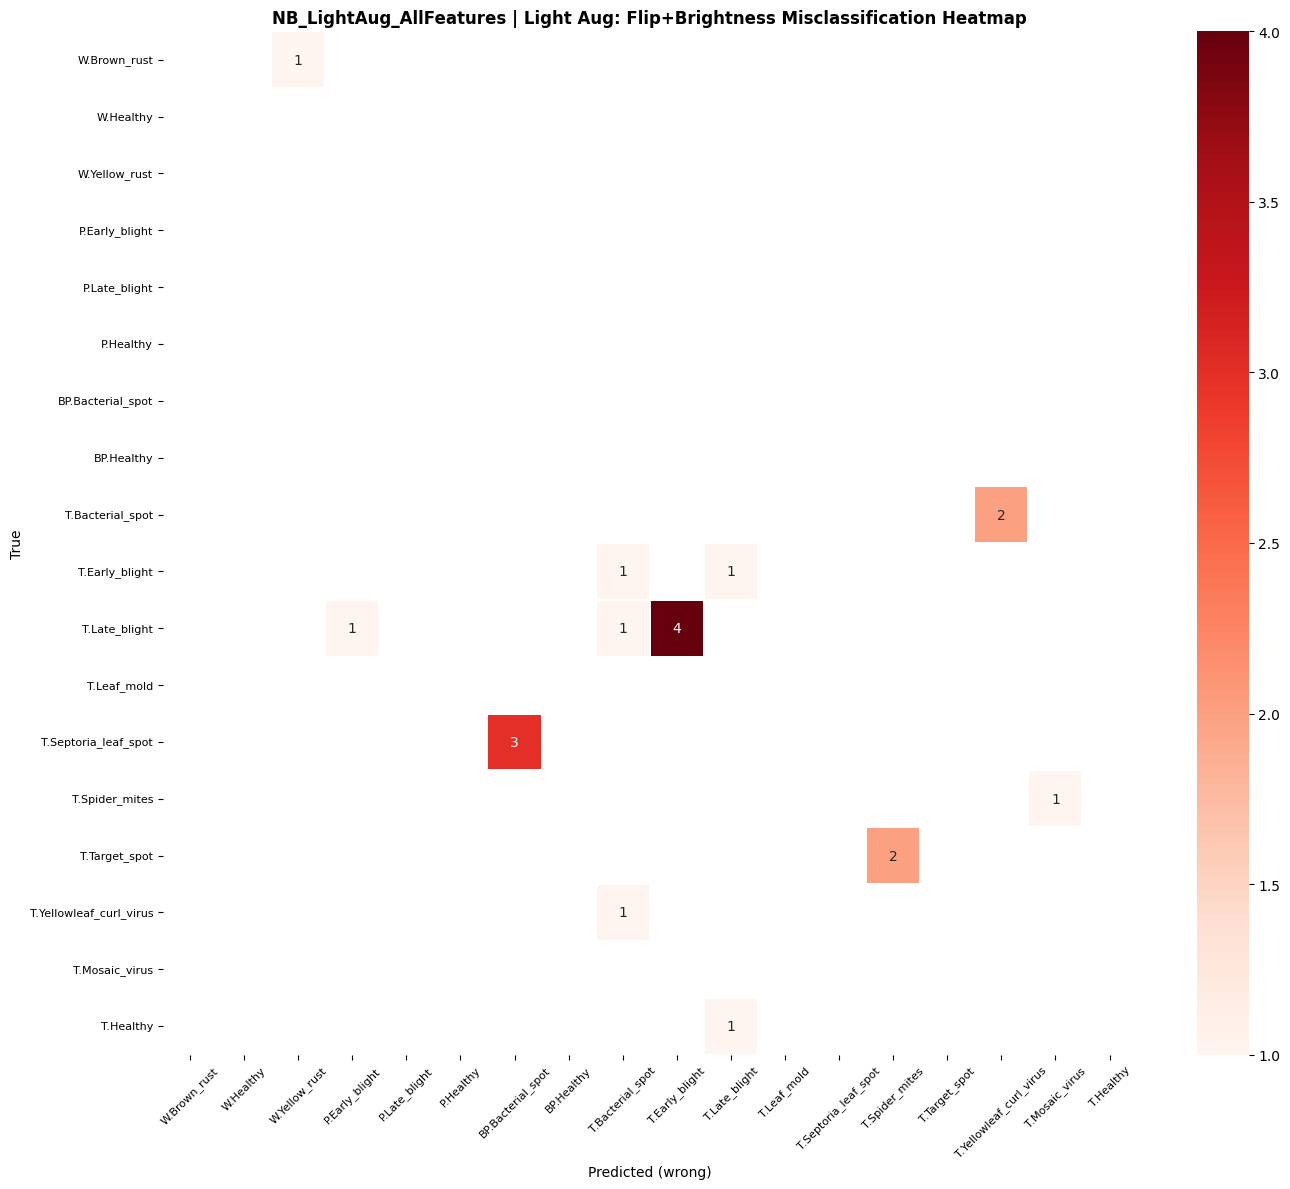

In [14]:
# 3. Misclassification Heatmap
cm_err=cm.copy(); np.fill_diagonal(cm_err,0)
fig,ax=plt.subplots(figsize=(14,12))
sns.heatmap(cm_err,ax=ax,cmap='Reds',annot=True,fmt='d',
            xticklabels=short,yticklabels=short,linewidths=0.3,linecolor='white',
            mask=(cm_err==0))
ax.set_title(NOTEBOOK_ID+' | '+AUG_STRATEGY+' Misclassification Heatmap',fontweight='bold')
ax.set_xlabel('Predicted (wrong)'); ax.set_ylabel('True')
ax.tick_params(axis='x',rotation=45,labelsize=8); ax.tick_params(axis='y',rotation=0,labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'misclassification_heatmap.png'),dpi=130,bbox_inches='tight'); plt.show()


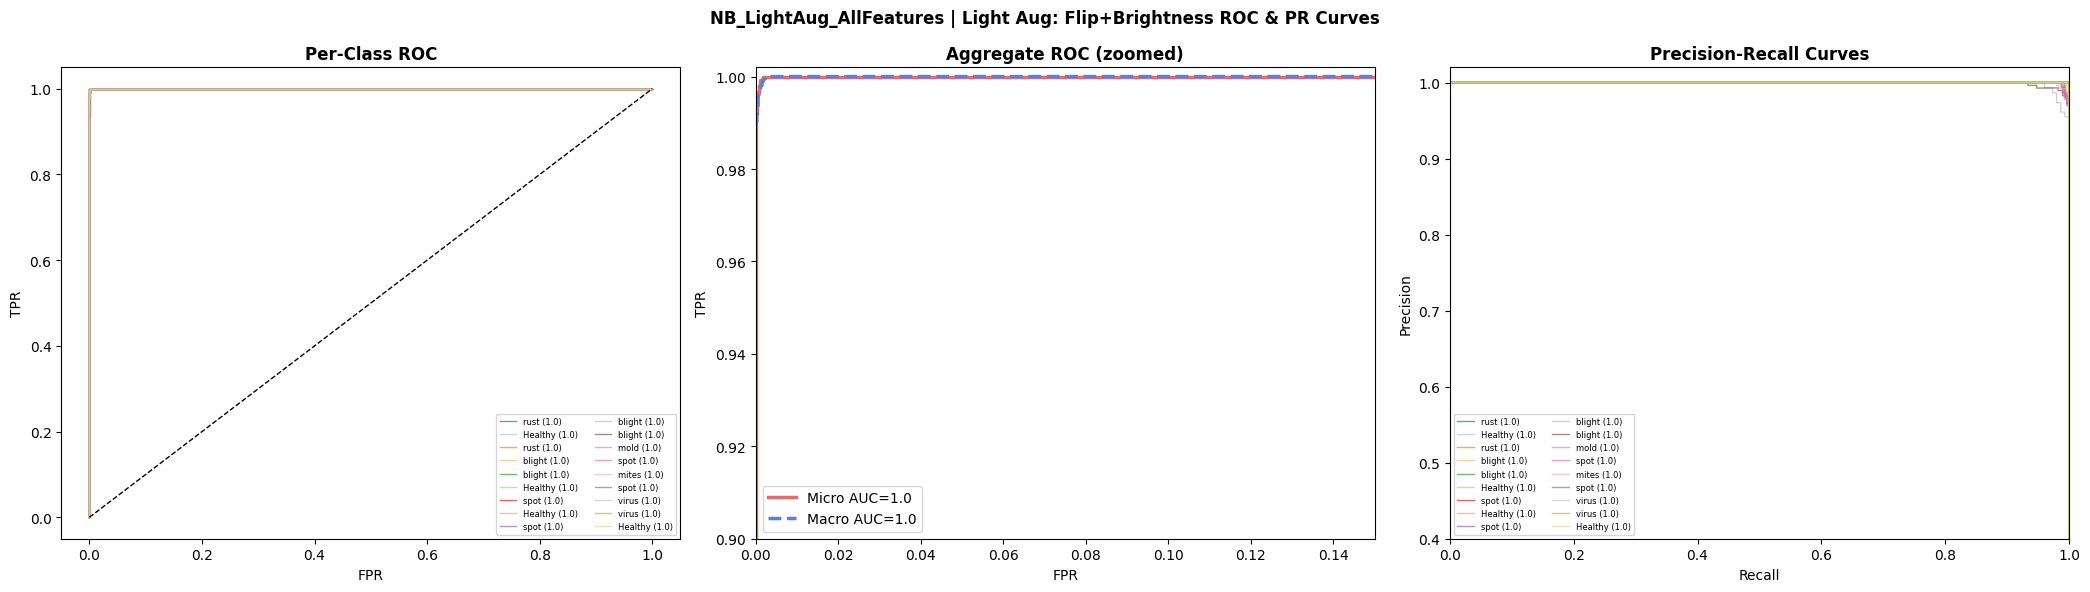

Micro AUC=1.0  Macro AUC=1.0


In [15]:
# 4. ROC + PR Curves
y_bin=label_binarize(y_true,classes=list(range(NUM_CLASSES)))
fpr_d,tpr_d,roc_auc_d,pr_ap={},{},{},{}
for i in range(NUM_CLASSES):
    fpr_d[i],tpr_d[i],_=roc_curve(y_bin[:,i],y_prob[:,i]); roc_auc_d[i]=auc(fpr_d[i],tpr_d[i])
    pr_ap[i]=average_precision_score(y_bin[:,i],y_prob[:,i])

fpr_d['micro'],tpr_d['micro'],_=roc_curve(y_bin.ravel(),y_prob.ravel())
roc_auc_d['micro']=auc(fpr_d['micro'],tpr_d['micro'])
all_fpr=np.unique(np.concatenate([fpr_d[i] for i in range(NUM_CLASSES)]))
mean_tpr=np.zeros_like(all_fpr)
for i in range(NUM_CLASSES): mean_tpr+=np.interp(all_fpr,fpr_d[i],tpr_d[i])
mean_tpr/=NUM_CLASSES; roc_auc_d['macro']=auc(all_fpr,mean_tpr)

fig,axes=plt.subplots(1,3,figsize=(21,6))
for i,color in zip(range(NUM_CLASSES),cycle(plt.cm.tab20.colors)):
    axes[0].plot(fpr_d[i],tpr_d[i],color=color,lw=1,alpha=0.7,
                 label=TARGET_CLASSES[i].split('_')[-1]+' ('+str(round(roc_auc_d[i],2))+')')
axes[0].plot([0,1],[0,1],'k--',lw=1); axes[0].set_title('Per-Class ROC',fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=6,ncol=2)

axes[1].plot(fpr_d['micro'],tpr_d['micro'],'#E86B6B',lw=2.5,label='Micro AUC='+str(round(roc_auc_d["micro"],4)))
axes[1].plot(all_fpr,mean_tpr,'#5B7FDE',lw=2.5,ls='--',label='Macro AUC='+str(round(roc_auc_d["macro"],4)))
axes[1].plot([0,1],[0,1],'k--',lw=1); axes[1].set_xlim([0,0.15]); axes[1].set_ylim([0.9,1.002])
axes[1].set_title('Aggregate ROC (zoomed)',fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend(fontsize=10)

for i,color in zip(range(NUM_CLASSES),cycle(plt.cm.tab20.colors)):
    p_i,r_i,_=precision_recall_curve(y_bin[:,i],y_prob[:,i])
    axes[2].plot(r_i,p_i,color=color,lw=1,alpha=0.7,
                 label=TARGET_CLASSES[i].split('_')[-1]+' ('+str(round(pr_ap[i],2))+')')
axes[2].set_title('Precision-Recall Curves',fontweight='bold')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_xlim([0,1]); axes[2].set_ylim([0.4,1.02]); axes[2].legend(fontsize=6,ncol=2)

plt.suptitle(NOTEBOOK_ID+' | '+AUG_STRATEGY+' ROC & PR Curves',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'roc_pr_curves.png'),dpi=130,bbox_inches='tight'); plt.show()
print('Micro AUC='+str(round(roc_auc_d["micro"],4))+'  Macro AUC='+str(round(roc_auc_d["macro"],4)))


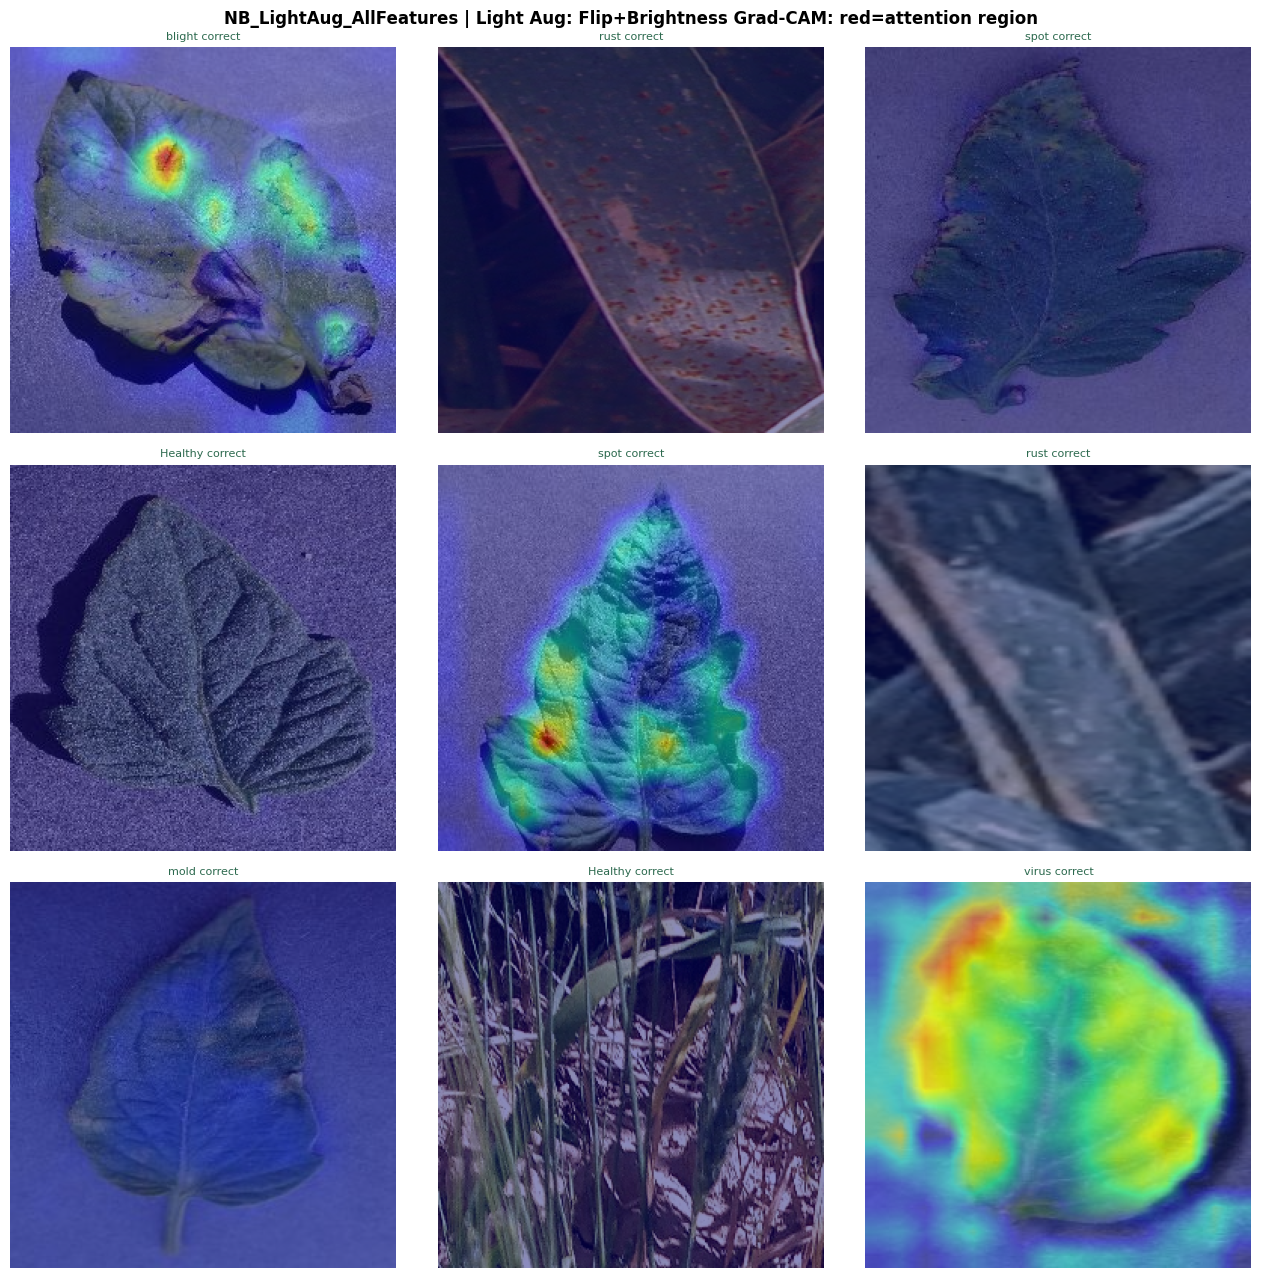

In [16]:
# 5. Grad-CAM
try: import cv2
except: os.system('pip install opencv-python-headless -q'); import cv2

last_conv=next(l.name for l in reversed(model.layers)
               if isinstance(l,(tf.keras.layers.Conv2D,tf.keras.layers.MaxPooling2D)))
grad_model=tf.keras.Model(inputs=model.input,
                           outputs=[model.get_layer(last_conv).output,model.output])

def gradcam(img_t,cls_idx):
    with tf.GradientTape() as tape:
        conv_out,preds=grad_model(img_t[tf.newaxis],training=False)
        score=preds[0][cls_idx]
    grads=tape.gradient(score,conv_out)[0]
    weights=tf.reduce_mean(grads,axis=[0,1])
    cam=tf.reduce_sum(conv_out[0]*weights,axis=-1).numpy()
    cam=np.maximum(cam,0); cam/=(cam.max()+1e-8)
    return cv2.resize(cam,(256,256))

def overlay(img_np,cam):
    hm=cv2.cvtColor(cv2.applyColorMap(np.uint8(255*cam),cv2.COLORMAP_JET),cv2.COLOR_BGR2RGB)/255.0
    return np.clip(0.55*img_np+0.45*hm,0,1)

random.seed(SEED)
sample_cls=random.sample(TARGET_CLASSES,9)
fig,axes=plt.subplots(3,3,figsize=(13,13))
for ax,cls in zip(axes.flatten(),sample_cls):
    imgs=get_images(os.path.join(UNIFIED_DIR,cls))
    if not imgs: ax.axis('off'); continue
    path=random.choice(imgs)
    raw=tf.io.read_file(path)
    img_t=tf.cast(tf.image.resize(tf.image.decode_image(raw,channels=3,expand_animations=False),IMG_SIZE),tf.float32)/255.0
    cls_idx=CLASS_TO_IDX[cls]
    cam=gradcam(img_t,cls_idx)
    over=overlay(img_t.numpy(),cam)
    pred=np.argmax(model(img_t[tf.newaxis],training=False).numpy()[0])
    correct=pred==cls_idx; col='#2d6a4f' if correct else '#c1121f'
    ax.imshow(over)
    verdict = 'correct' if correct else 'wrong: '+IDX_TO_CLASS[pred].split('_')[-1]
    ax.set_title(cls.split('_')[-1]+' '+verdict, fontsize=8, color=col)
    for sp in ax.spines.values(): sp.set_edgecolor(col); sp.set_linewidth(2)
    ax.axis('off')
plt.suptitle(NOTEBOOK_ID+' | '+AUG_STRATEGY+' Grad-CAM: red=attention region',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'gradcam.png'),dpi=130,bbox_inches='tight'); plt.show()


40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step
t-SNE on 2500 samples x 224 dims ...


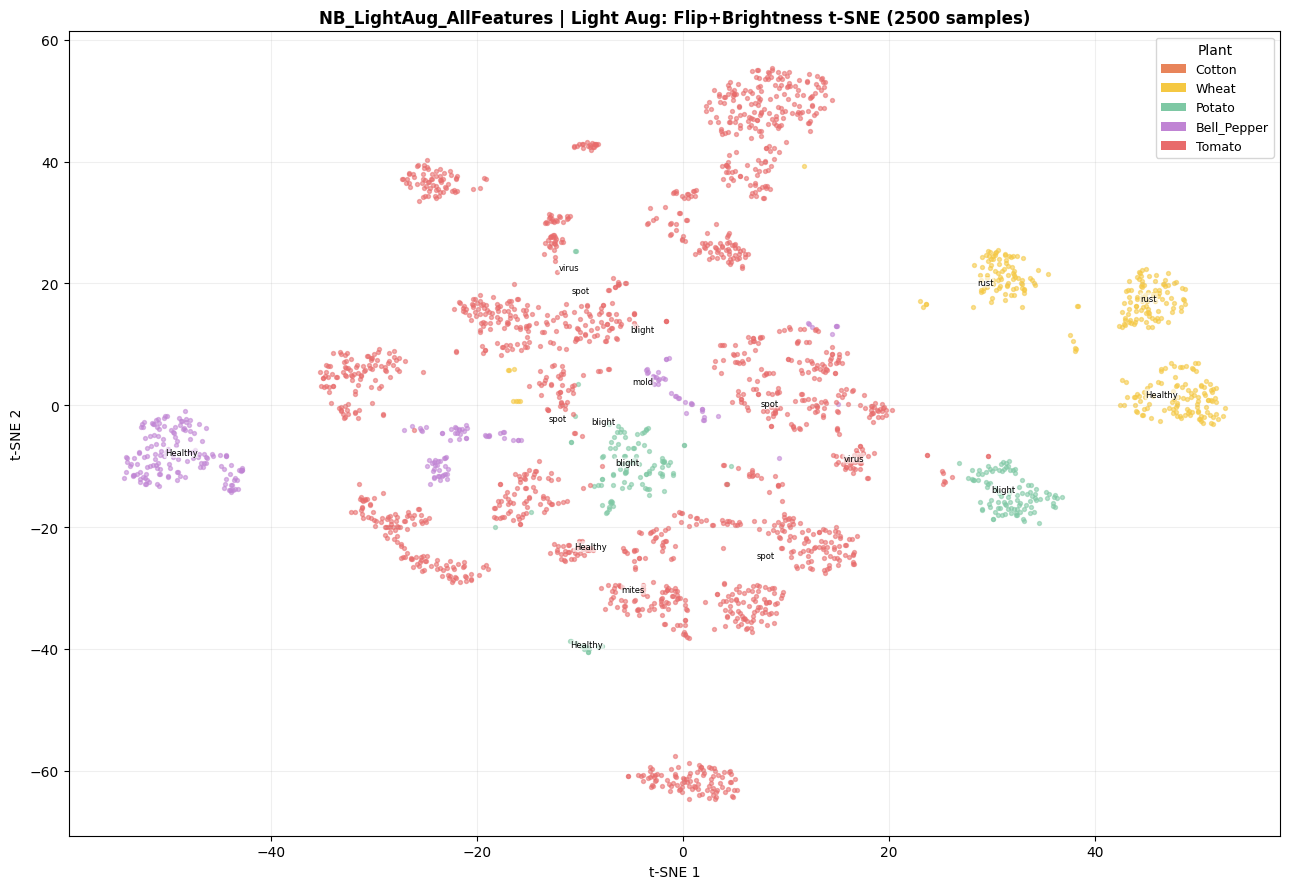

In [17]:
# 6. t-SNE Feature Space
gap_layer_name='gap' if 'gap' in [l.name for l in model.layers] else model.layers[-4].name
gap_model=tf.keras.Model(inputs=model.input,outputs=model.get_layer(gap_layer_name).output)

MAX_T=2500
X_sub=X_te[:MAX_T]; y_sub=y_te[:MAX_T]
ds_sub=tf.data.Dataset.from_tensor_slices((X_sub,y_sub)).map(
    lambda p,l: (tf.cast(tf.image.resize(
        tf.image.decode_image(tf.io.read_file(p),channels=3,expand_animations=False),
        IMG_SIZE),tf.float32)/255.0, l)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
feats=gap_model.predict(ds_sub,verbose=1)[:MAX_T]; lbl_s=y_sub[:len(feats)]

print('t-SNE on '+str(len(feats))+' samples x '+str(feats.shape[1])+' dims ...')
emb=TSNE(n_components=2,perplexity=40,n_iter=1000,random_state=SEED).fit_transform(feats)

PCOLS={'Cotton':'#E8845A','Wheat':'#F5C842','Potato':'#7EC8A4','Bell_Pepper':'#C084D4','Tomato':'#E86B6B'}
def pcol(cls):
    for k in PCOLS:
        if cls.startswith(k): return PCOLS[k]
    return '#888'

fig,ax=plt.subplots(figsize=(13,9))
for ci,cls in enumerate(TARGET_CLASSES):
    mask=lbl_s==ci
    if not mask.any(): continue
    ax.scatter(emb[mask,0],emb[mask,1],s=8,alpha=0.55,color=pcol(cls))
    cx,cy=emb[mask,0].mean(),emb[mask,1].mean()
    ax.text(cx,cy,cls.split('_')[-1][:7],fontsize=6,ha='center',
            bbox=dict(boxstyle='round,pad=0.1',facecolor='white',alpha=0.6,edgecolor='none'))

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=v,label=k) for k,v in PCOLS.items()],title='Plant',fontsize=9)
ax.set_title(NOTEBOOK_ID+' | '+AUG_STRATEGY+' t-SNE ('+str(len(feats))+' samples)',fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2'); ax.grid(True,alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'tsne.png'),dpi=130,bbox_inches='tight'); plt.show()


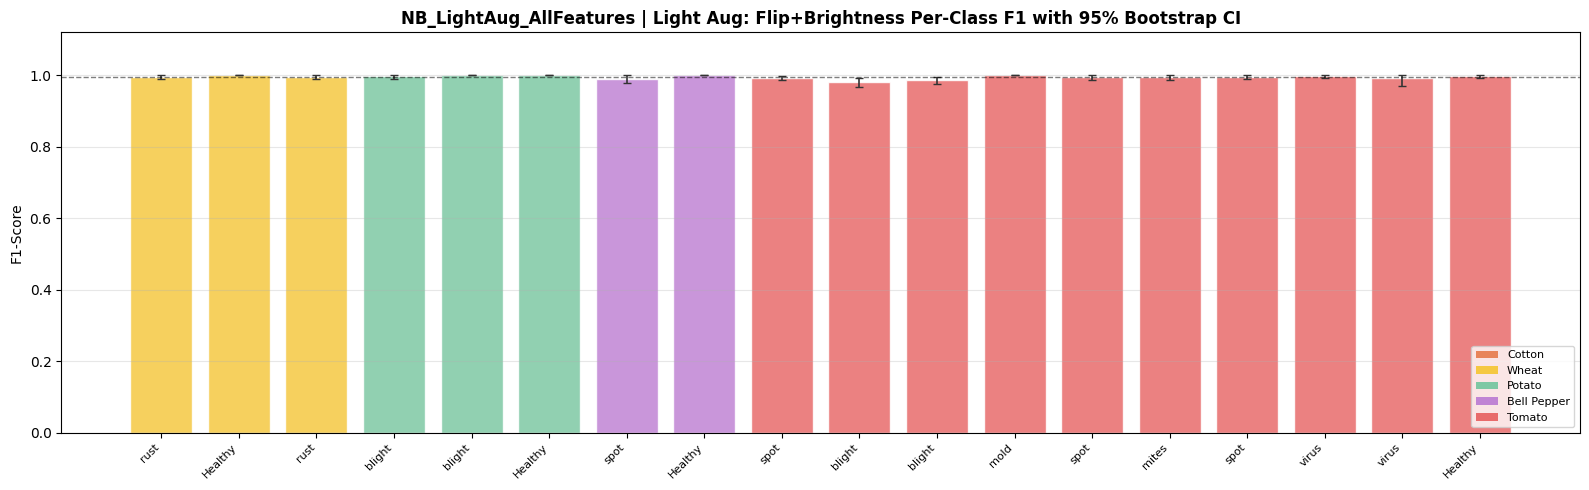

In [18]:
# 7. Per-class F1 with Bootstrap CI
N_BOOT=200; boot_f1s={cls:[] for cls in TARGET_CLASSES}
rng=np.random.default_rng(SEED)
for _ in range(N_BOOT):
    idx=rng.choice(len(y_true),len(y_true),replace=True)
    yt_b=y_true[idx]; yp_b=y_pred[idx]
    for ci,cls in enumerate(TARGET_CLASSES):
        tp=np.sum((yt_b==ci)&(yp_b==ci)); fp=np.sum((yt_b!=ci)&(yp_b==ci)); fn=np.sum((yt_b==ci)&(yp_b!=ci))
        boot_f1s[cls].append((2*tp)/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0)

means=[np.mean(boot_f1s[c]) for c in TARGET_CLASSES]
ci_lo=[np.percentile(boot_f1s[c],2.5) for c in TARGET_CLASSES]
ci_hi=[np.percentile(boot_f1s[c],97.5) for c in TARGET_CLASSES]

plant_colors=['#E8845A' if c.startswith('Cotton') else '#F5C842' if c.startswith('Wheat')
              else '#7EC8A4' if c.startswith('Potato') else '#C084D4' if c.startswith('Bell') else '#E86B6B'
              for c in TARGET_CLASSES]

fig,ax=plt.subplots(figsize=(16,5))
x=np.arange(NUM_CLASSES)
ax.bar(x,means,color=plant_colors,alpha=0.85,edgecolor='white')
yerr_lo=np.abs([m-l for m,l in zip(means,ci_lo)])
yerr_hi=np.abs([h-m for h,m in zip(ci_hi,means)])
ax.errorbar(x,means,yerr=[yerr_lo,yerr_hi],
            fmt='none',color='#333',capsize=3,lw=1.2)
ax.set_xticks(x); ax.set_xticklabels([c.split('_')[-1][:8] for c in TARGET_CLASSES],rotation=45,ha='right',fontsize=8)
ax.set_ylim(0,1.12); ax.set_ylabel('F1-Score'); ax.grid(True,axis='y',alpha=0.3)
ax.axhline(np.mean(means),color='black',ls='--',lw=1,alpha=0.5,label='Mean='+str(round(float(np.mean(means)),3)))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#E8845A',label='Cotton'),Patch(facecolor='#F5C842',label='Wheat'),
    Patch(facecolor='#7EC8A4',label='Potato'),Patch(facecolor='#C084D4',label='Bell Pepper'),
    Patch(facecolor='#E86B6B',label='Tomato')],fontsize=8,loc='lower right')
ax.set_title(NOTEBOOK_ID+' | '+AUG_STRATEGY+' Per-Class F1 with 95% Bootstrap CI',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'per_class_f1_ci.png'),dpi=130,bbox_inches='tight'); plt.show()


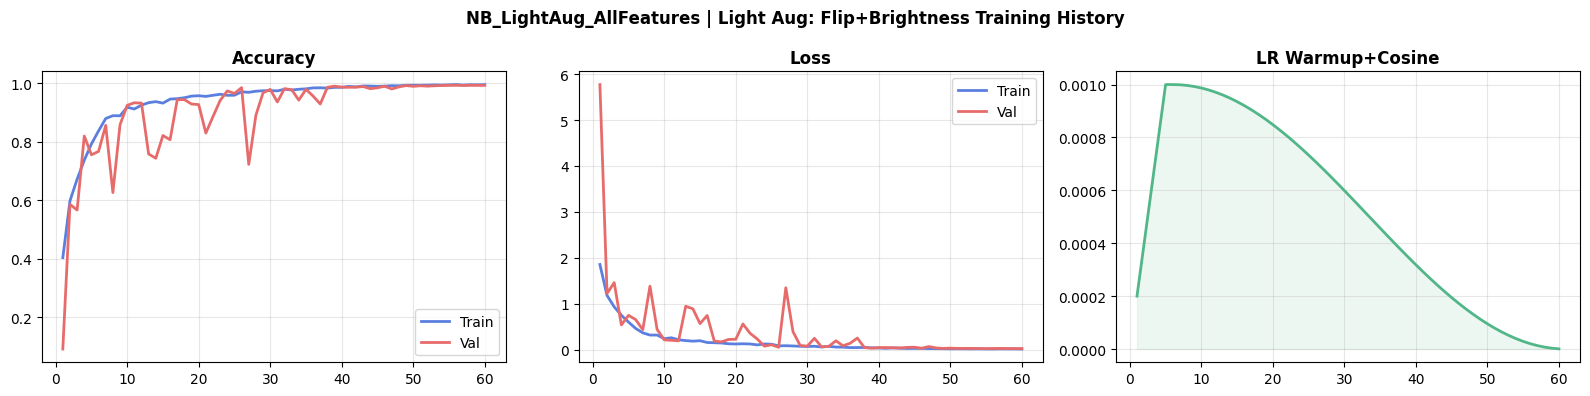

FINAL: acc=0.9946 f1=0.9946 macro_auc=1.0
All files saved to /root/plant_project/NB_LightAug_AllFeatures/logs/visualizations


In [19]:
# 8. Training curves + save all
hist=history.history; n_ep=range(1,len(hist['loss'])+1)
fig,axes=plt.subplots(1,3,figsize=(16,4))
axes[0].plot(n_ep,hist['accuracy'],label='Train',color='#5B7FDE',lw=2)
axes[0].plot(n_ep,hist['val_accuracy'],label='Val',color='#E86B6B',lw=2)
axes[0].set_title('Accuracy',fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(n_ep,hist['loss'],label='Train',color='#5B7FDE',lw=2)
axes[1].plot(n_ep,hist['val_loss'],label='Val',color='#E86B6B',lw=2)
axes[1].set_title('Loss',fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)
lrs=[CosineWarmupScheduler(INITIAL_LR,EPOCHS)._sched(e,0) for e in range(len(hist['loss']))]
axes[2].plot(n_ep,lrs,color='#52B788',lw=2); axes[2].fill_between(n_ep,lrs,alpha=0.1,color='#52B788')
axes[2].set_title('LR Warmup+Cosine',fontweight='bold'); axes[2].grid(alpha=0.3)
plt.suptitle(NOTEBOOK_ID+' | '+AUG_STRATEGY+' Training History',fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(LOG_DIR,'training_curves.png'),dpi=120,bbox_inches='tight'); plt.show()

pd.DataFrame(hist).assign(epoch=range(1,len(hist['loss'])+1),notebook=NOTEBOOK_ID,
    aug=AUG_STRATEGY,train_time_sec=train_time,total_params=model.count_params()
).to_csv(os.path.join(LOG_DIR,'training_history.csv'),index=False)

pd.DataFrame([{'notebook':NOTEBOOK_ID,'aug_strategy':AUG_STRATEGY,'accuracy':acc,
    'precision':prec,'recall':rec,'f1':f1,'specificity':float(np.mean(spec_list)),
    'params':model.count_params(),'train_time_min':train_time/60,'model_size_mb':sz_mb,
    'single_inf_ms':single_ms,'per_img_batch_ms':per_img_ms,
    'peak_train_mem_mb':peak_mem/1e6,'peak_inf_mem_mb':inf_peak/1e6,
    'micro_auc':roc_auc_d['micro'],'macro_auc':roc_auc_d['macro'],
    'mean_ap':float(np.mean(list(pr_ap.values()))),'best_val_acc':max(hist['val_accuracy'])
}]).to_csv(os.path.join(LOG_DIR,'metrics_summary.csv'),index=False)

pd.DataFrame({'class':TARGET_CLASSES,'f1_mean':means,'ci_lo':ci_lo,'ci_hi':ci_hi,
    'sensitivity':[rd[c]['recall'] for c in TARGET_CLASSES],
    'precision_cls':[rd[c]['precision'] for c in TARGET_CLASSES],
    'specificity':spec_list,'support':[rd[c]['support'] for c in TARGET_CLASSES]
}).to_csv(os.path.join(LOG_DIR,'per_class_metrics.csv'),index=False)

pd.DataFrame({'class':list(range(NUM_CLASSES))+['micro','macro'],
    'class_name':TARGET_CLASSES+['micro_avg','macro_avg'],
    'roc_auc':[roc_auc_d[i] for i in range(NUM_CLASSES)]+[roc_auc_d['micro'],roc_auc_d['macro']],
    'avg_precision':list(pr_ap.values())+[float(np.mean(list(pr_ap.values())))]*2
}).to_csv(os.path.join(LOG_DIR,'roc_auc.csv'),index=False)

np.save(os.path.join(LOG_DIR,'y_prob.npy'),y_prob); np.save(os.path.join(LOG_DIR,'y_true.npy'),y_true)
model.save(os.path.join(BASE_DIR,'model.h5'))
with open(os.path.join(BASE_DIR,'class_mapping.json'),'w') as f:
    json.dump({'idx_to_class':IDX_TO_CLASS,'class_to_idx':CLASS_TO_IDX,'notebook':NOTEBOOK_ID,'aug':AUG_STRATEGY},f,indent=2)

import shutil
dst=os.path.join('/kaggle/working','plant_project',NOTEBOOK_ID)
if os.path.exists(dst): shutil.rmtree(dst)
shutil.copytree(BASE_DIR,dst)
print('FINAL: acc='+str(round(acc,4))+' f1='+str(round(f1,4))+' macro_auc='+str(round(roc_auc_d["macro"],4)))
print('All files saved to '+VIZ_DIR)
